In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os

In [3]:
data = fetch_lfw_people(min_faces_per_person=2, resize=1.0, color=True)
images, labels = data.images, data.target
images = images.astype(np.float32)

batch_size = 32
epochs = 20

# Making data preprocessing

In [4]:
def preprocess_images(imgs):
    imgs = imgs.astype(np.float32) / 255.0
    imgs = tf.image.resize(imgs, (100, 100)).numpy()
    return imgs

def create_pairs(images, labels, num_pairs=10000, mode="bce"):
    label_to_indices = {label: np.where(labels == label)[0] for label in np.unique(labels)}
    unique_labels = list(label_to_indices.keys())
    pairs = []
    pair_labels = []

    for _ in range(num_pairs):
        if mode == "triplet":
            anchor_label = np.random.choice(unique_labels)
            negative_label = np.random.choice([l for l in unique_labels if l != anchor_label])
            anchor_idx = np.random.choice(label_to_indices[anchor_label])
            pos_idx = np.random.choice(label_to_indices[anchor_label])
            neg_idx = np.random.choice(label_to_indices[negative_label])
            pairs.append((images[anchor_idx], images[pos_idx], images[neg_idx]))
        else:
            if np.random.rand() < 0.5:
                label = np.random.choice(unique_labels)
                i1, i2 = np.random.choice(label_to_indices[label], 2, replace=False)
                pairs.append((images[i1], images[i2]))
                pair_labels.append(1 if mode == "bce" else 0)
            else:
                l1, l2 = np.random.choice(unique_labels, 2, replace=False)
                i1 = np.random.choice(label_to_indices[l1])
                i2 = np.random.choice(label_to_indices[l2])
                pairs.append((images[i1], images[i2]))
                pair_labels.append(0 if mode == "bce" else 1)
    return pairs if mode == "triplet" else (pairs, pair_labels)

# Called the model

In [5]:
class L2Normalization(layers.Layer):
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

def create_embedding_model(input_shape=(100, 100, 3), embedding_dim=128):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(embedding_dim)(x)
    out = L2Normalization()(x)
    return models.Model(inputs, out)

# Build different loss function

In [6]:
def bce_loss():
    def loss(y_true, y_pred):
        emb1, emb2 = y_pred[:, :128], y_pred[:, 128:]
        similarity = tf.reduce_sum(emb1 * emb2, axis=1)
        return tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=similarity)
    return lambda y_true, y_pred: tf.reduce_mean(loss(y_true, y_pred))

def contrastive_loss(margin=1.0, epsilon=1e-6):
    def loss(y_true, y_pred):
        emb1, emb2 = y_pred[:, :128], y_pred[:, 128:]
        dist = tf.norm(emb1 - emb2, axis=1) + epsilon
        return tf.reduce_mean(y_true * tf.square(dist) + (1 - y_true) * tf.square(tf.maximum(margin - dist, 0)))
    return loss

def triplet_loss(margin=1.0, epsilon=1e-6):
    def loss(_, y_pred):
        a = y_pred[:, :128]
        p = y_pred[:, 128:256]
        n = y_pred[:, 256:]

        d_ap = tf.reduce_sum(tf.square(a - p), axis=1)  # ||a - p||²
        d_an = tf.reduce_sum(tf.square(a - n), axis=1)  # ||a - n||²

        loss_val = tf.maximum(d_ap - d_an + margin, 0.0)
        return tf.reduce_mean(loss_val)
    return loss

# Model Call

In [7]:
def build_bce_or_contrastive_model(embedding_model):
    i1, i2 = layers.Input((100,100,3)), layers.Input((100,100,3))
    e1, e2 = embedding_model(i1), embedding_model(i2)
    out = layers.Concatenate()([e1, e2])
    return models.Model([i1, i2], out)

def build_triplet_model(embedding_model):
    ia, ip, ineg = layers.Input((100,100,3)), layers.Input((100,100,3)), layers.Input((100,100,3))
    ea, ep, en = embedding_model(ia), embedding_model(ip), embedding_model(ineg)
    out = layers.Concatenate()([ea, ep, en])
    return models.Model([ia, ip, ineg], out)

# Datasets

In [8]:
def make_tf_dataset(pairs, labels, batch_size):
    i1 = preprocess_images(np.array([p[0] for p in pairs]))
    i2 = preprocess_images(np.array([p[1] for p in pairs]))
    labels = np.array(labels).astype(np.float32)
    return tf.data.Dataset.from_tensor_slices(((i1, i2), labels)).shuffle(10000).batch(batch_size).prefetch(1)

def make_triplet_dataset(triplets, batch_size):
    a = preprocess_images(np.array([t[0] for t in triplets]))
    p = preprocess_images(np.array([t[1] for t in triplets]))
    n = preprocess_images(np.array([t[2] for t in triplets]))
    return tf.data.Dataset.from_tensor_slices(((a, p, n), np.zeros(len(triplets)))).shuffle(10000).batch(batch_size).prefetch(1)

# Plot images and training graph

In [9]:
def plot_training(history, title):
    plt.plot(history.history['loss'])
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

def visualize_sample_pairs(pairs, labels, title, n=5):
    plt.figure(figsize=(n*2, 4))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(pairs[i][0])
        plt.axis('off')
        plt.subplot(2, n, n+i+1)
        plt.imshow(pairs[i][1])
        plt.axis('off')
        plt.title(f"Label: {int(labels[i])}")
    plt.suptitle(title)
    plt.show()
def visualize_triplets(triplets, n=5):
    plt.figure(figsize=(16, 14))
    for i in range(n):
        for j in range(3):  # anchor, pos, neg
            plt.subplot(n, 3, 3*i + j + 1)
            plt.imshow(triplets[i][j])
            plt.axis('off')
            plt.title(['Anchor', 'Positive', 'Negative'][j])
    plt.show()

# BCE Trainig and plotting


Training BCE model...


W0000 00:00:1753193145.876797   14885 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-07-22 20:05:45.879164: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 705000000 exceeds 10% of free system memory.
2025-07-22 20:05:46.231126: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 600000000 exceeds 10% of free system memory.
2025-07-22 20:05:47.139805: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 705000000 exceeds 10% of free system memory.
2025-07-22 20:05:47.459447: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 600000000 exceeds 10% of free system memory.
2025-07-22 20:05:48.11391

Epoch 1/20
157/157 - 76s - 483ms/step - loss: 0.8048
Epoch 2/20
157/157 - 78s - 494ms/step - loss: 0.8079
Epoch 3/20
157/157 - 70s - 447ms/step - loss: 0.8094
Epoch 4/20
157/157 - 70s - 447ms/step - loss: 0.8033
Epoch 5/20
157/157 - 70s - 446ms/step - loss: 0.8007
Epoch 6/20
157/157 - 70s - 445ms/step - loss: 0.8012
Epoch 7/20
157/157 - 70s - 448ms/step - loss: 0.8104
Epoch 8/20
157/157 - 71s - 449ms/step - loss: 0.8104
Epoch 9/20
157/157 - 71s - 453ms/step - loss: 0.7964
Epoch 10/20
157/157 - 71s - 455ms/step - loss: 0.8039
Epoch 11/20
157/157 - 74s - 469ms/step - loss: 0.8104
Epoch 12/20
157/157 - 81s - 516ms/step - loss: 0.8104
Epoch 13/20
157/157 - 74s - 474ms/step - loss: 0.8104
Epoch 14/20
157/157 - 72s - 456ms/step - loss: 0.8102
Epoch 15/20
157/157 - 72s - 457ms/step - loss: 0.7987
Epoch 16/20
157/157 - 71s - 449ms/step - loss: 0.8100
Epoch 17/20
157/157 - 70s - 446ms/step - loss: 0.7573
Epoch 18/20
157/157 - 71s - 455ms/step - loss: 0.7771
Epoch 19/20
157/157 - 70s - 447ms/ste

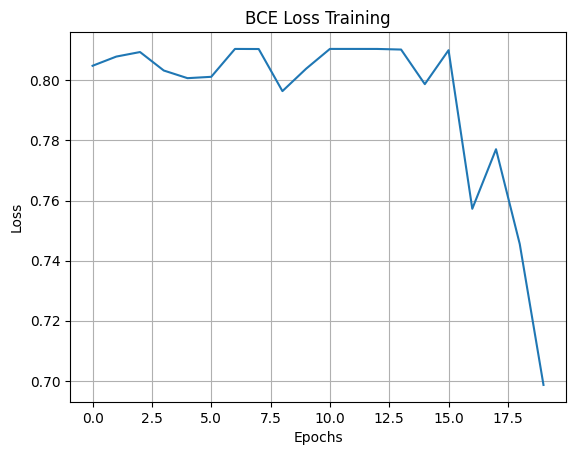

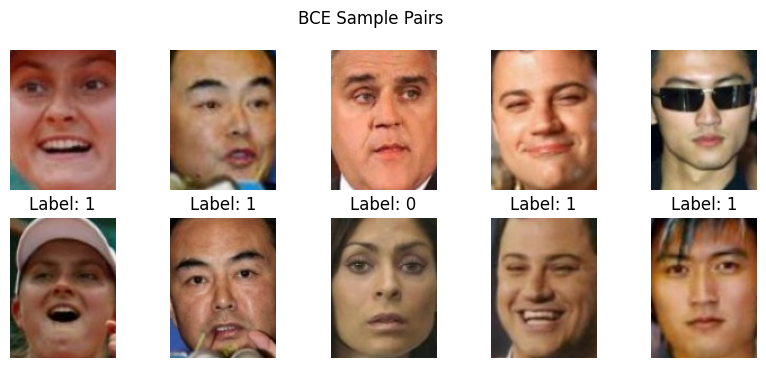

In [10]:
print("\nTraining BCE model...")
pairs_bce, labels_bce = create_pairs(images, labels, num_pairs=5000, mode="bce")
dataset_bce = make_tf_dataset(pairs_bce, labels_bce, batch_size)
model_bce = build_bce_or_contrastive_model(create_embedding_model())
model_bce.compile(optimizer=optimizers.Adam(1e-4), loss=bce_loss())
history_bce = model_bce.fit(dataset_bce, epochs=epochs, verbose=2)
plot_training(history_bce, "BCE Loss Training")
visualize_sample_pairs(pairs_bce, labels_bce, "BCE Sample Pairs")

# Contrastive Training and plotting


Training Contrastive model...
Epoch 1/20
157/157 - 71s - 454ms/step - loss: 0.3152
Epoch 2/20
157/157 - 69s - 442ms/step - loss: 0.2899
Epoch 3/20
157/157 - 70s - 443ms/step - loss: 0.2716
Epoch 4/20
157/157 - 70s - 443ms/step - loss: 0.2605
Epoch 5/20
157/157 - 70s - 443ms/step - loss: 0.2501
Epoch 6/20
157/157 - 70s - 444ms/step - loss: 0.2422
Epoch 7/20
157/157 - 69s - 442ms/step - loss: 0.2323
Epoch 8/20
157/157 - 69s - 442ms/step - loss: 0.2181
Epoch 9/20
157/157 - 82s - 522ms/step - loss: 0.2108
Epoch 10/20
157/157 - 82s - 521ms/step - loss: 0.1998
Epoch 11/20
157/157 - 70s - 444ms/step - loss: 0.1932
Epoch 12/20
157/157 - 70s - 443ms/step - loss: 0.1842
Epoch 13/20
157/157 - 69s - 441ms/step - loss: 0.1765
Epoch 14/20
157/157 - 69s - 442ms/step - loss: 0.1659
Epoch 15/20
157/157 - 70s - 445ms/step - loss: 0.1597
Epoch 16/20
157/157 - 69s - 442ms/step - loss: 0.1507
Epoch 17/20
157/157 - 70s - 444ms/step - loss: 0.1409
Epoch 18/20
157/157 - 69s - 442ms/step - loss: 0.1336
Epoch 

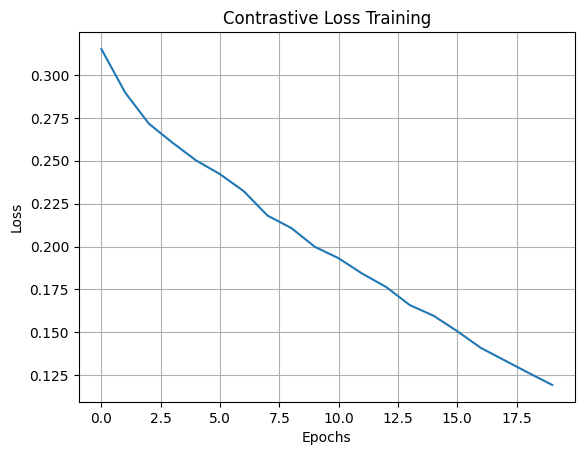

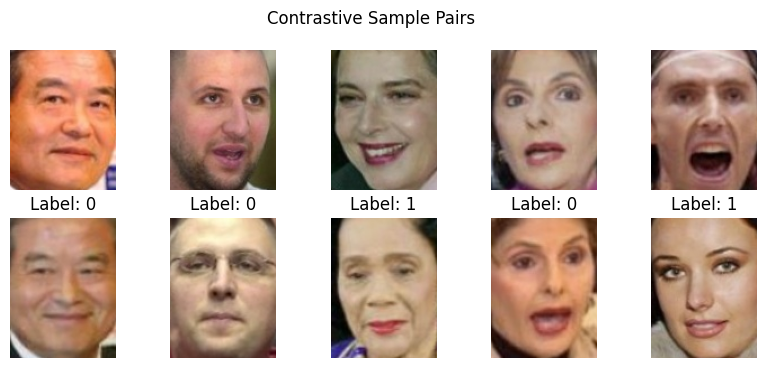

In [11]:
print("\nTraining Contrastive model...")
pairs_cont, labels_cont = create_pairs(images, labels, num_pairs=5000, mode="contrastive")
dataset_cont = make_tf_dataset(pairs_cont, labels_cont, batch_size)
model_cont = build_bce_or_contrastive_model(create_embedding_model())
model_cont.compile(optimizer=optimizers.Adam(1e-4), loss=contrastive_loss())
history_cont = model_cont.fit(dataset_cont, epochs=epochs, verbose=2)
plot_training(history_cont, "Contrastive Loss Training")
visualize_sample_pairs(pairs_cont, labels_cont, "Contrastive Sample Pairs")

# Triplet Training and Plotting


Training Triplet model...
Epoch 1/20
157/157 - 99s - 630ms/step - loss: 0.6349
Epoch 2/20
157/157 - 97s - 615ms/step - loss: 0.4507
Epoch 3/20
157/157 - 96s - 613ms/step - loss: 0.4019
Epoch 4/20
157/157 - 97s - 616ms/step - loss: 0.3474
Epoch 5/20
157/157 - 97s - 615ms/step - loss: 0.3179
Epoch 6/20
157/157 - 97s - 616ms/step - loss: 0.2824
Epoch 7/20
157/157 - 141s - 899ms/step - loss: 0.2627
Epoch 8/20
157/157 - 97s - 616ms/step - loss: 0.2386
Epoch 9/20
157/157 - 96s - 614ms/step - loss: 0.2201
Epoch 10/20
157/157 - 97s - 616ms/step - loss: 0.1932
Epoch 11/20
157/157 - 96s - 613ms/step - loss: 0.1656
Epoch 12/20
157/157 - 142s - 906ms/step - loss: 0.1420
Epoch 13/20
157/157 - 97s - 615ms/step - loss: 0.1137
Epoch 14/20
157/157 - 96s - 615ms/step - loss: 0.0920
Epoch 15/20
157/157 - 96s - 613ms/step - loss: 0.0736
Epoch 16/20
157/157 - 97s - 616ms/step - loss: 0.0556
Epoch 17/20
157/157 - 96s - 613ms/step - loss: 0.0433
Epoch 18/20
157/157 - 97s - 616ms/step - loss: 0.0295
Epoch 19

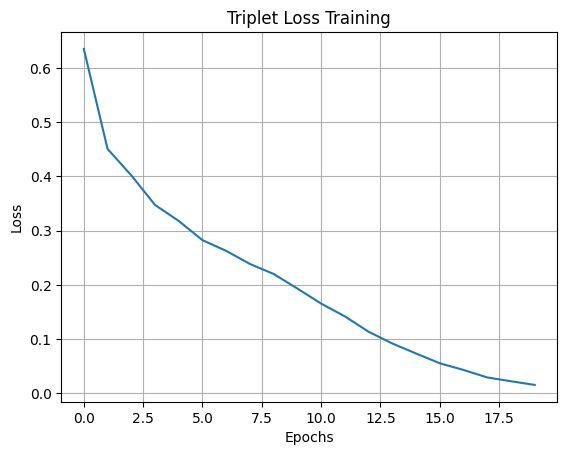

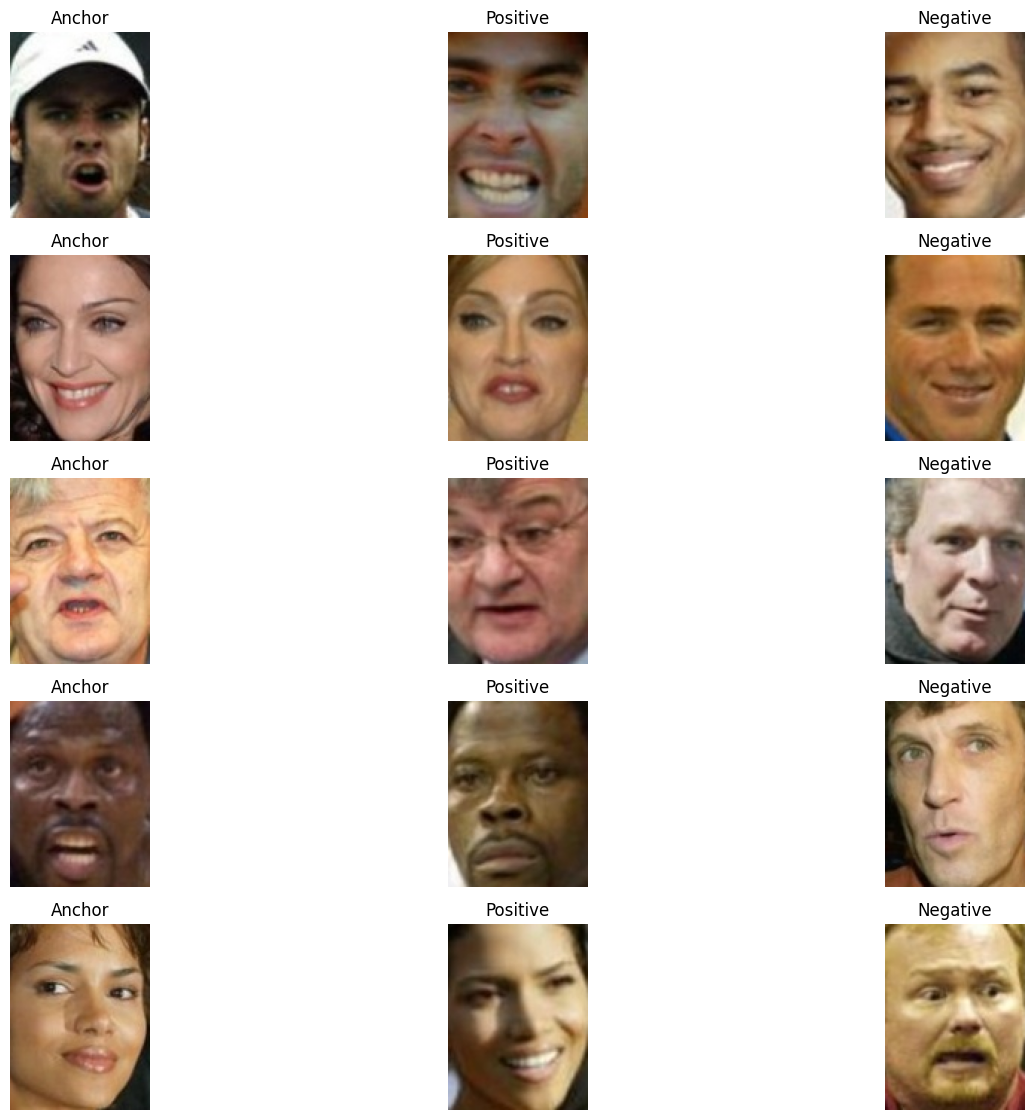

In [12]:
print("\nTraining Triplet model...")
triplets = create_pairs(images, labels, num_pairs=5000, mode="triplet")
dataset_triplet = make_triplet_dataset(triplets, batch_size)
model_triplet = build_triplet_model(create_embedding_model())
model_triplet.compile(optimizer=optimizers.Adam(1e-4), loss=triplet_loss())
history_triplet = model_triplet.fit(dataset_triplet, epochs=epochs, verbose=2)
plot_training(history_triplet, "Triplet Loss Training")
visualize_triplets(triplets, n=5)

# All result

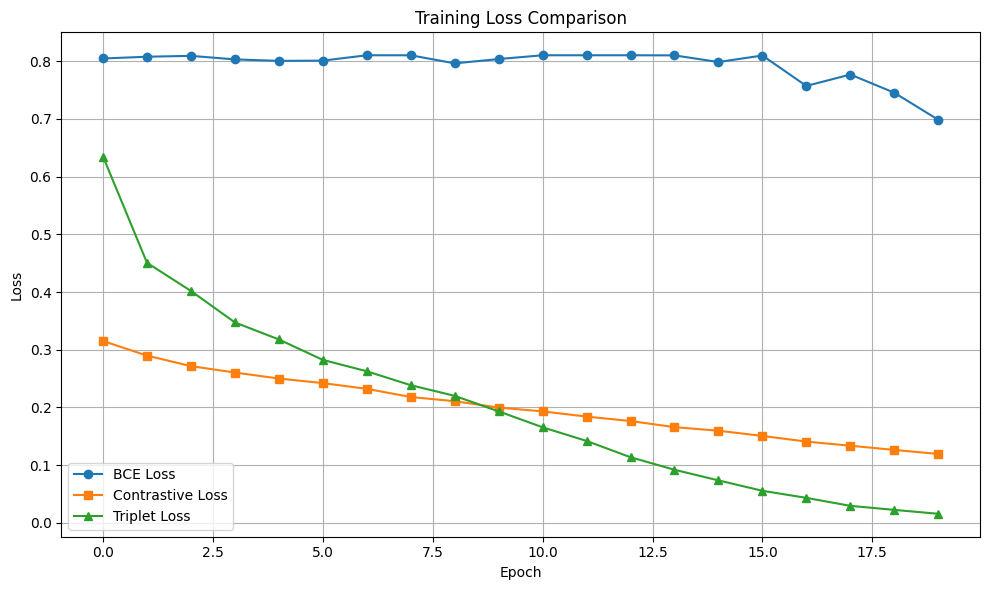

In [13]:
def plot_all_losses(history_bce, history_cont, history_triplet, title="Training Loss Comparison"):
    plt.figure(figsize=(10, 6))
    plt.plot(history_bce.history['loss'], label='BCE Loss', marker='o')
    plt.plot(history_cont.history['loss'], label='Contrastive Loss', marker='s')
    plt.plot(history_triplet.history['loss'], label='Triplet Loss', marker='^')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_all_losses(history_bce, history_cont, history_triplet)